# ... 2 ...

# Workflow Database

In [1]:
from cosim import Flow
from db import Flowdb

* List available workflows

In [2]:
Flowdb.List()

['flow_1', 'flow_2']

* Select a workflow 

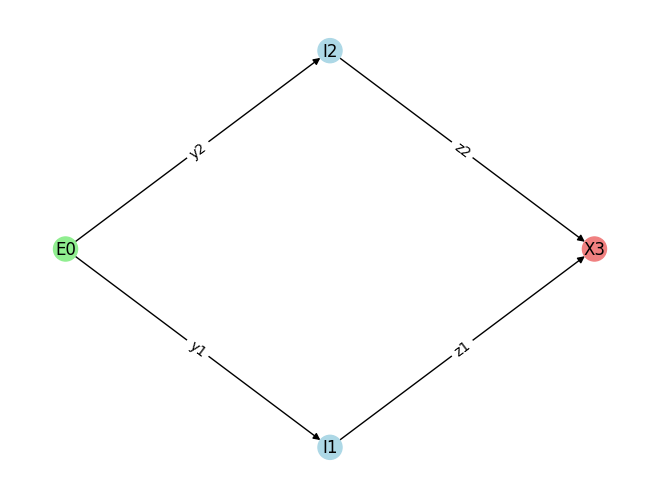

Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 0.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 0.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 0.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 0.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 0.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 0.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 0.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 0.0}


In [3]:
flow_name = 'flow_2'
flow = Flow(flow_name, Flowdb.Get(flow_name))
flow.render()
print(flow)

* Inpect attributes

In [4]:
flow.NAME, flow.NODES, flow.ENTRY, flow.EXIT

('flow_2', ['E0', 'I1', 'I2', 'X3'], 'E0', 'X3')

In [5]:
flow.__dict__

{'graph': {},
 '_node': {'E0': {'inputs': ('x',),
   'outputs': ('y1', 'y2'),
   'size': 0.0,
   'decision': None,
   'subset': 0},
  'I1': {'inputs': ('y1',),
   'outputs': ('z1',),
   'size': 0.0,
   'decision': None,
   'subset': 1},
  'I2': {'inputs': ('y2',),
   'outputs': ('z2',),
   'size': 0.0,
   'decision': None,
   'subset': 1},
  'X3': {'inputs': ('z1', 'z2'),
   'outputs': ('o',),
   'size': 0.0,
   'decision': None,
   'subset': 2}},
 '_adj': {'E0': {'I1': {'data': 'y1', 'size': 0.0},
   'I2': {'data': 'y2', 'size': 0.0}},
  'I1': {'X3': {'data': 'z1', 'size': 0.0}},
  'I2': {'X3': {'data': 'z2', 'size': 0.0}},
  'X3': {}},
 '_succ': {'E0': {'I1': {'data': 'y1', 'size': 0.0},
   'I2': {'data': 'y2', 'size': 0.0}},
  'I1': {'X3': {'data': 'z1', 'size': 0.0}},
  'I2': {'X3': {'data': 'z2', 'size': 0.0}},
  'X3': {}},
 '_pred': {'E0': {},
  'I1': {'E0': {'data': 'y1', 'size': 0.0}},
  'I2': {'E0': {'data': 'y2', 'size': 0.0}},
  'X3': {'I1': {'data': 'z1', 'size': 0.0},
   '

* Set task and data sizes

In [6]:
import random
flow = flow * [random.randint(5, 19) for _ in flow.nodes] # set task sizes
flow = flow / [random.randint(15, 99) for _ in flow.edges] # set data sizes
print(flow)

Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 18.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 12.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 12.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 6.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 54.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 57.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 64.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 34.0}


## Executing a flow

* is required to obtain real values for task sizes (in cycles) and data sizes (in bytes) for tasks in a workflow

In [7]:
import os
from cosim import Executor, Kio, timestamp

pyexe = 'python'
codepath = os.path.abspath('__db__/flowed')
datapath = os.path.join(codepath, f'data_{timestamp()}')
os.makedirs(datapath, exist_ok=True)

input_path = os.path.join(datapath, flow.nodes[flow.ENTRY]['inputs'][0])
input_value = 12 #int(input())
Kio.SavePICK(input_path, input_value)


result = Executor(
    flow=flow,
    pyexe=pyexe,
    codepath=codepath,
    datapath=datapath,
    verbose=True,
)

output_path = os.path.join(datapath, flow.nodes[flow.EXIT]['outputs'][0])
output_value = Kio.LoadPICK(output_path)

print(f'{output_value=}')



Executor start
	codepath='/home/ava/Server/Code/GitHub/cosim/__db__/flowed'
	datapath='/home/ava/Server/Code/GitHub/cosim/__db__/flowed/data_20260125054914420092'
Flow:
Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 18.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 12.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 12.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 6.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 54.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 57.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 64.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 34.0}

Task in Q: 4
Can Run 1 tasks: ['E0']
Task start: E0
Task End: E0
	cycles: 94725874
	instructions: 110161134
	elapsed: 0.030878765
	prefs: 0.06357766699511558
	Processing task output: y1
	Processing task output: y2

Task in Q: 3
Can Run 2 tasks: ['I1', 'I2']
Task 

In [8]:
result

{'exe': {'E0': {'outputs': {'y1': 5, 'y2': 5},
   'cycles': 94725874,
   'instructions': 110161134,
   'elapsed': 0.030878765,
   'prefs': 0.06357766699511558},
  'I1': {'outputs': {'z1': 5},
   'cycles': 97640070,
   'instructions': 114206438,
   'elapsed': 3.04311782,
   'prefs': 3.0652996550197713},
  'I2': {'outputs': {'z2': 5},
   'cycles': 104254690,
   'instructions': 114247475,
   'elapsed': 5.04587464,
   'prefs': 5.065478490025271},
  'X3': {'outputs': {'o': 18},
   'cycles': 93667469,
   'instructions': 110090824,
   'elapsed': 0.041121494,
   'prefs': 0.06295132997911423}},
 'task': {'E0': 94725874, 'I1': 97640070, 'I2': 104254690, 'X3': 93667469},
 'data': {('E0', 'I1'): 5, ('E0', 'I2'): 5, ('I1', 'X3'): 5, ('I2', 'X3'): 5}}

In [9]:
result_ = result

In [10]:
result_

{'exe': {'E0': {'outputs': {'y1': 5, 'y2': 5},
   'cycles': 94725874,
   'instructions': 110161134,
   'elapsed': 0.030878765,
   'prefs': 0.06357766699511558},
  'I1': {'outputs': {'z1': 5},
   'cycles': 97640070,
   'instructions': 114206438,
   'elapsed': 3.04311782,
   'prefs': 3.0652996550197713},
  'I2': {'outputs': {'z2': 5},
   'cycles': 104254690,
   'instructions': 114247475,
   'elapsed': 5.04587464,
   'prefs': 5.065478490025271},
  'X3': {'outputs': {'o': 18},
   'cycles': 93667469,
   'instructions': 110090824,
   'elapsed': 0.041121494,
   'prefs': 0.06295132997911423}},
 'task': {'E0': 94725874, 'I1': 97640070, 'I2': 104254690, 'X3': 93667469},
 'data': {('E0', 'I1'): 5, ('E0', 'I2'): 5, ('I1', 'X3'): 5, ('I2', 'X3'): 5}}

In [11]:
flow = flow * result_['task'] # set task sizes
flow = flow / result_['data'] # set data sizes
print(flow)

Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 94725874.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 97640070.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 104254690.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 93667469.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 5.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 5.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 5.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 5.0}
